In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [2]:
df =  fetch_california_housing()

In [3]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [4]:
dataset = pd.DataFrame(df.data,columns=df.feature_names)

In [5]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
dataset["Price"] = df.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
##independent Feature
X = dataset.drop(columns="Price")
y = dataset["Price"]

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
regression = LinearRegression()

In [10]:
regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
from sklearn.model_selection import cross_val_score

In [12]:
mse = cross_val_score(regression,X,y,scoring="neg_mean_squared_error",cv=5)

In [13]:
mse

array([-0.48485857, -0.62249739, -0.64621047, -0.5431996 , -0.49468484])

In [41]:
mse_scores = cross_val_score(regression, X, y, 
                             scoring="neg_mean_squared_error", 
                             cv=5)

# Convert negative MSE to positive
mse_scores = -mse_scores
print("MSE for each fold:", mse_scores)
print("Average MSE:", mse_scores.mean())
print("RMSE (average):", np.sqrt(mse_scores.mean()))

MSE for each fold: [0.48485857 0.62249739 0.64621047 0.5431996  0.49468484]
Average MSE: 0.558290171768655
RMSE (average): 0.747188176946514


### Ridge Regression

In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [19]:
rigde = Ridge()

In [21]:
rigde

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [23]:
parameter = {"alpha":[1e-15,1e-2,1e-8,30,50,10,20]}

In [33]:
rigde_regression = GridSearchCV(rigde,parameter,scoring='neg_mean_squared_error',verbose=1 ,cv=5)
rigde_regression.fit(X,y)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 0.01, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,50


In [37]:
print(rigde_regression.best_params_)
print(rigde_regression.best_score_)

{'alpha': 50}
-0.5579557674778975


### Lasso Regression

In [42]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(X,y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

d:\Data_Science\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.314e+03, tolerance: 2.228e+00
  model = cd_fast.enet_coordinate_descent(
d:\Data_Science\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.429e+02, tolerance: 2.256e+00
  model = cd_fast.enet_coordinate_descent(
d:\Data_Science\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.663e+03, tolerance: 2.110e

{'alpha': 0.001}
-0.5582759293868984


In [43]:
from sklearn.model_selection import train_test_split


In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [67]:
lasso_predicted = lasso_regressor.predict(X_test)
rigde_predicted = rigde_regression.predict(X_test)
regression.fit(X,y)
regression_predicted = regression.predict(X_test)

In [50]:
import seaborn as sns

<Figure size 100x100 with 0 Axes>

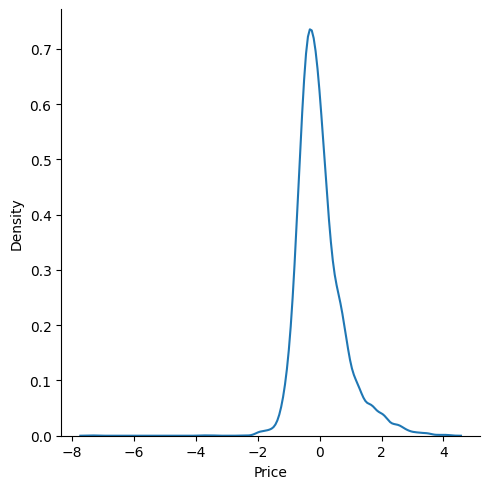

In [68]:
plt.figure(figsize=(1,1))
sns.displot(y_test-regression_predicted, kind='kde')

<Figure size 100x100 with 0 Axes>

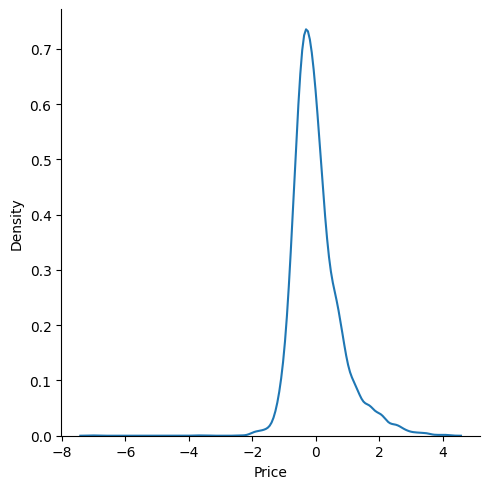

In [61]:
plt.figure(figsize=(1,1))
sns.displot(y_test-lasso_predicted, kind='kde')


<Figure size 100x100 with 0 Axes>

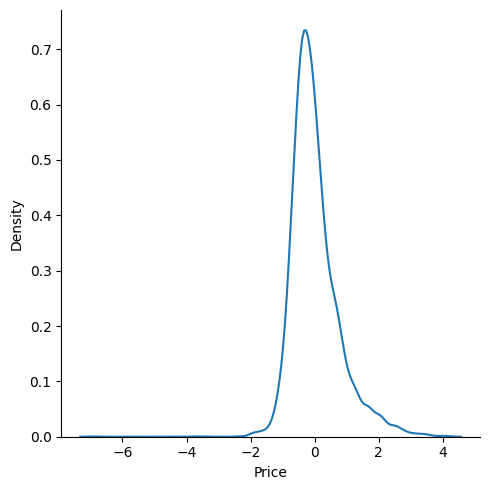

In [62]:
plt.figure(figsize=(1,1))
sns.displot(y_test-rigde_predicted, kind='kde')


In [63]:
from sklearn.metrics import r2_score

In [64]:
r2_score(y_test,lasso_predicted)

0.586332557951088

In [65]:
r2_score(y_test,rigde_predicted)

0.5864172106843238